In [ ]:
import pandas as pd

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"../data/raw/sales.csv")

In [ ]:
df.isnull().sum()

Row ID+O6G3A1:R6    0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Profit              0
Payment Mode        0
dtype: int64

How big this data is

In [ ]:
df.shape[0]  # Number of rows
df.shape[1]  # Number of columns

20

In [ ]:
# how does the data look like
df.sample(5)

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Payment Mode
1887,4486,CA-2019-109365,2019-11-03,2019-11-08,Standard Class,XP-21865,Xylona Preis,Consumer,United States,Los Angeles,California,West,OFF-PA-10000477,Office Supplies,Paper,Xerox 22,19.440,3,9.3312,Cards
2963,8785,US-2020-129224,2020-03-17,2020-03-23,Standard Class,AS-10630,Ann Steele,Home Office,United States,Knoxville,Tennessee,South,OFF-LA-10003190,Office Supplies,Labels,Avery 474,127.608,2,1.6704,Online
4391,1966,CA-2020-110905,2020-09-10,2020-09-15,Second Class,RW-19690,Robert Waldorf,Consumer,United States,Springfield,Missouri,Central,OFF-AP-10003281,Office Supplies,Appliances,Acco 6 Outlet Guardian Standard Surge Suppressor,104.180,2,7.2540,Online
2083,9587,CA-2019-108630,2019-11-18,2019-11-18,Same Day,BE-11410,Bobby Elias,Consumer,United States,Concord,California,West,OFF-BI-10002437,Office Supplies,Binders,Recycled Premium Regency Composition Covers,61.120,5,22.1560,Online
2569,8725,US-2019-135209,2019-12-29,2019-12-31,Second Class,MH-17290,Marc Harrigan,Home Office,United States,Miami,Florida,South,OFF-PA-10000143,Office Supplies,Paper,Astroparche Fine Business Paper,25.344,6,8.8704,Online


In [ ]:
# what is the datatypes of cols?
df.dtypes

Row ID+O6G3A1:R6      int64
Order ID             object
Order Date           object
Ship Date            object
Ship Mode            object
Customer ID          object
Customer Name        object
Segment              object
Country              object
City                 object
State                object
Region               object
Product ID           object
Category             object
Sub-Category         object
Product Name         object
Sales               float64
Quantity              int64
Profit              float64
Payment Mode         object
dtype: object

In [ ]:
df= df.rename(columns={'Order ID':"order_id", 'Order Date':"order_date", 'Ship Date':'ship_date', 'Ship Mode':'ship_mode',
        'Customer ID':'customer_id', 'Customer Name':'customer_name', 'Segment':'segment', 'Country':'country', 'City':'city', 'State':'state',
        'Region':'region', 'Product ID':'product_id', 'Category':'category', 'Sub-Category':'sub_category', 'Product Name':'product_name',
        'Sales':'sales', 'Quantity':'quantity', 'Profit':'profit', 'Payment Mode':'payment_mode', 'avg profit':'avg_profit',
        'Profit status':'profit_status', 'Days Between Delivery':'days_between_delivery', 'Avg delivery date':'avg_delivery_date',
        'Delivery_remarks':'delivery_remark'})

In [ ]:
# correct date formats
df["order_date"] = pd.to_datetime(df["order_date"],format='mixed', errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"],format='mixed', errors="coerce")

In [ ]:
# identify categorical columns and convert into category datatype
for col in df.columns:
    if df[col].nunique() < 10:   # we maka a assumption that if a column has less than 10 unique values, it is a categorical column
        print(col)
        df[col] = df[col].astype("category")



ship_mode
segment
country
region
category
payment_mode


In [ ]:
# what are the missing data
df.isnull().sum()

Row ID+O6G3A1:R6    0
order_id            0
order_date          0
ship_date           0
ship_mode           0
customer_id         0
customer_name       0
segment             0
country             0
city                0
state               0
region              0
product_id          0
category            0
sub_category        0
product_name        0
sales               0
quantity            0
profit              0
payment_mode        0
dtype: int64

In [ ]:
# is there any duplicate if how many
df.duplicated().sum()


np.int64(0)

In [ ]:
# summary of data
df.describe()

,Row ID+O6G3A1:R6,order_date,ship_date,sales,quantity,profit
count,5901.000000,5901,5901,5901.000000,5901.000000,5901.000000
mean,5022.422471,2020-02-29 01:53:57.620742144,2020-03-04 00:08:47.097102336,265.345589,3.781901,29.700408
min,1.000000,2019-01-01 00:00:00,2019-01-05 00:00:00,0.836000,1.000000,-6599.978000
25%,2486.000000,2019-09-11 00:00:00,2019-09-15 00:00:00,71.976000,2.000000,1.795500
50%,5091.000000,2020-03-16 00:00:00,2020-03-19 00:00:00,128.648000,3.000000,8.502500
75%,7456.000000,2020-09-14 00:00:00,2020-09-16 00:00:00,265.170000,5.000000,28.615000
max,9994.000000,2020-12-31 00:00:00,2021-01-05 00:00:00,9099.930000,14.000000,8399.976000
std,2877.977184,NaN,NaN,474.260645,2.212917,259.589138


In [ ]:
# how is the correlation between the numerical cols
df.corr(numeric_only=True)

,Row ID+O6G3A1:R6,sales,quantity,profit
Row ID+O6G3A1:R6,1.000000,0.019204,0.012414,0.018891
sales,0.019204,1.000000,0.202420,0.325915
quantity,0.012414,0.202420,1.000000,0.074761
profit,0.018891,0.325915,0.074761,1.000000


In [43]:
df.to_csv('new_sales.csv', index=False)

### Pushing to Git

To push your changes to a Git repository, you typically follow these steps:

1.  **Add all changed files**: This stages your changes for the next commit.
    ```bash
    git add .
    ```
2.  **Commit your changes**: This records the changes in the repository with a descriptive message.
    ```bash
    git commit -m "Descriptive commit message"
    ```
3.  **Push to the remote repository**: This uploads your local commits to the remote repository (e.g., GitHub, GitLab).
    ```bash
    git push
    ```

**Note**: Make sure you have configured your Git credentials and remote repository correctly.

## Univariate Analysis Interpretation

This section summarizes the insights gained from the univariate analysis of the dataset, looking at the distribution of individual features.

In [ ]:
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()

# Integer columns
integer_cols = df.select_dtypes(include=['int64',"float64" ,'int32']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Integer Columns:", integer_cols)

Categorical Columns: ['ship_mode', 'segment', 'country', 'region', 'category', 'payment_mode']
Integer Columns: ['Row ID+O6G3A1:R6', 'sales', 'quantity', 'profit']


################# for categorical columns #################################

segment
Consumer       2997
Corporate      1774
Home Office    1130
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Segments')

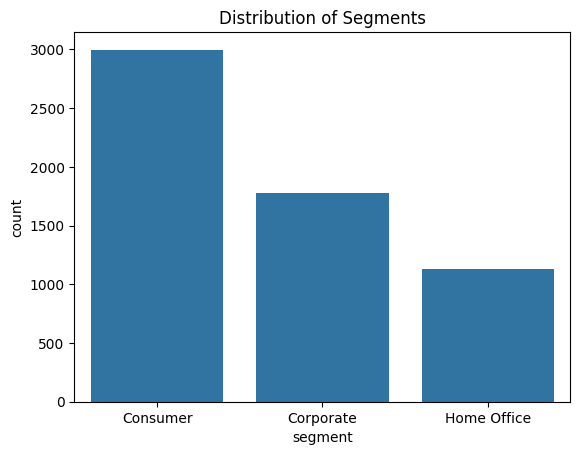

In [ ]:
print(df['segment'].value_counts())
sns.countplot(data=df, x="segment")
plt.title("Distribution of Segments")

payment_mode
COD       2453
Online    2164
Cards     1284
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Payment Modes')

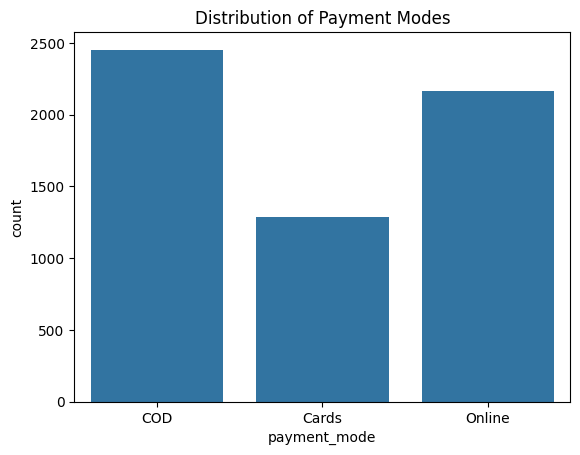

In [ ]:
print(df['payment_mode'].value_counts())
sns.countplot(x=df['payment_mode'])
plt.title("Distribution of Payment Modes")

region
West       1901
East       1688
Central    1381
South       931
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Regions')

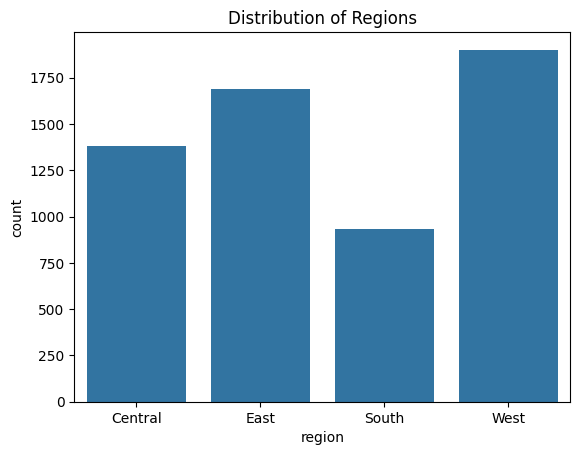

In [ ]:
print(df['region'].value_counts())
sns.countplot(data=df, x="region")
plt.title("Distribution of Regions")


country
United States    5901
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Countries')

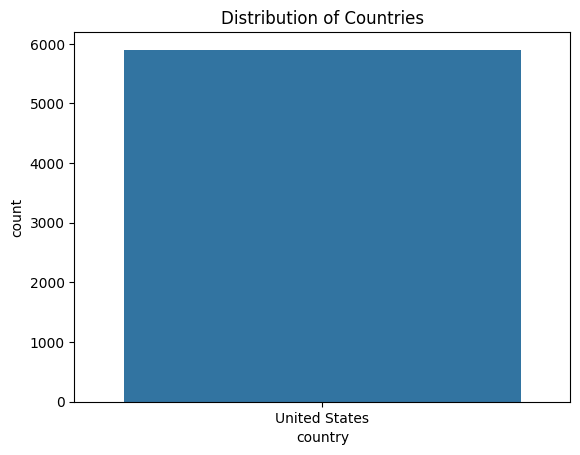

In [ ]:

print(df['country'].value_counts())
sns.countplot(x=df['country'])
plt.title("Distribution of Countries")

category
Office Supplies    3569
Furniture          1249
Technology         1083
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Categories')

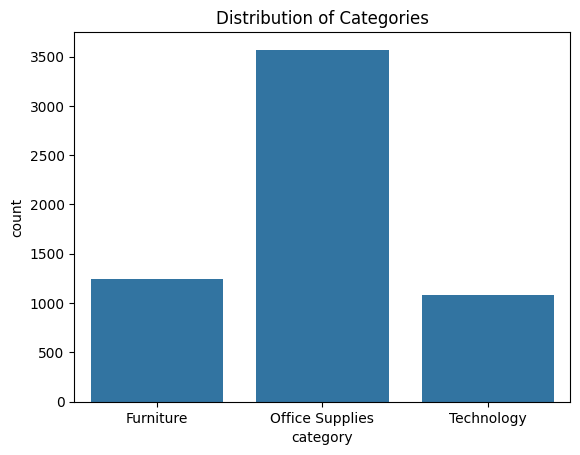

In [ ]:

print(df['category'].value_counts())
sns.countplot(data=df, x="category")
plt.title("Distribution of Categories")

ship_mode
Standard Class    3451
Second Class      1147
First Class        959
Same Day           344
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Ship Modes')

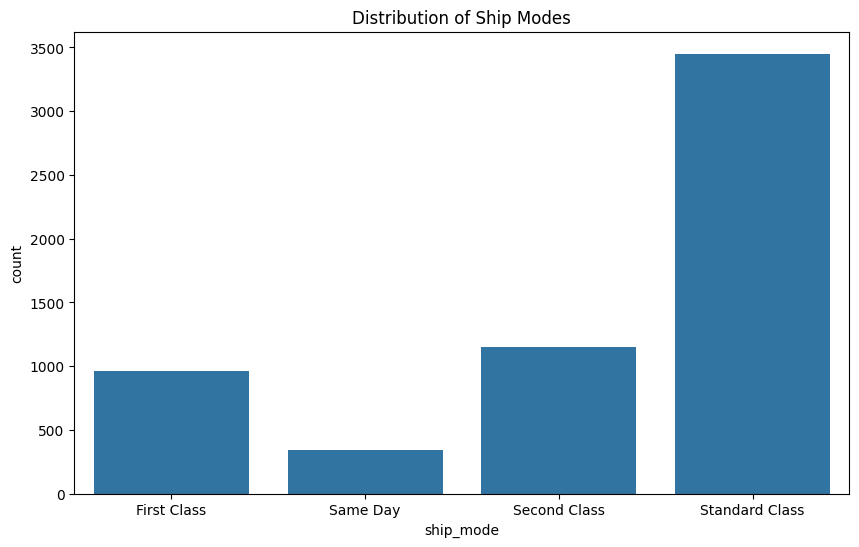

In [ ]:
plt.figure(figsize=(10, 6))
print(df['ship_mode'].value_counts())
sns.countplot(x=df['ship_mode'])
plt.title("Distribution of Ship Modes")

### Categorical Columns

**Segment:**
*   The 'Consumer' segment is the most dominant, followed by 'Corporate', and then 'Home Office'. This indicates that the majority of sales come from individual consumers.

**Payment Mode:**
*   'COD' (Cash on Delivery) is the most frequently used payment mode, followed closely by 'Online' payments, with 'Cards' being the least used. This suggests a preference for direct payment methods.

**Region:**
*   The 'West' and 'East' regions account for the highest number of orders, while the 'South' region has the fewest. This highlights geographical differences in sales activity.

**Country:**
*   All sales data originates from the 'United States', indicating that the dataset is geographically confined to a single country.

**Category:**
*   'Office Supplies' is by far the most sold category, significantly outnumbering 'Furniture' and 'Technology'. This suggests that office supplies are a core business product.

**Ship Mode:**
*   'Standard Class' is the most common shipping method, followed by 'Second Class', 'First Class', and then 'Same Day'. This implies that customers often opt for more economical shipping options.

##########################  For numerical columns #######################################

##########################   Sales ######################################

Text(0.5, 1.0, 'Distribution of Sales')

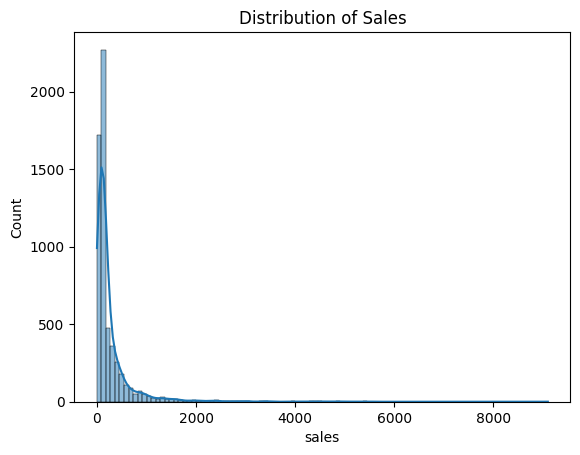

In [ ]:
summary=df['sales'].describe()
sns.histplot(df['sales'], bins=100, kde=True)
plt.title("Distribution of Sales")

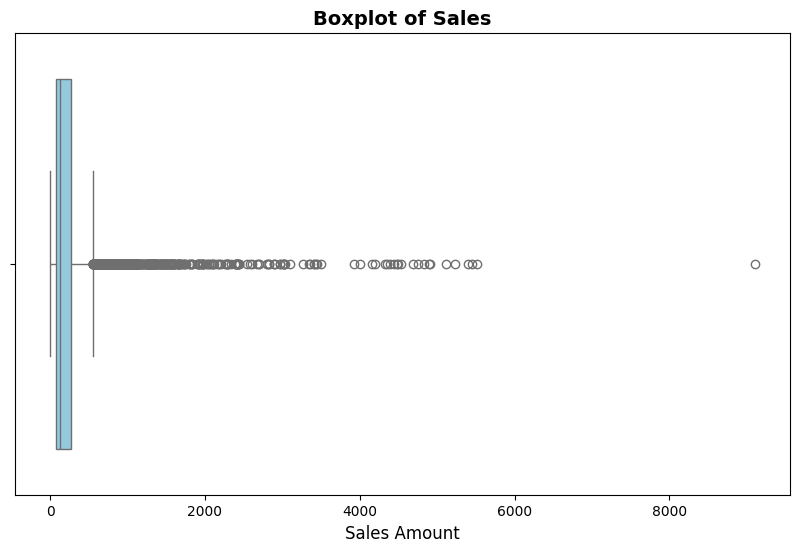

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['sales'], color='skyblue')
plt.title("Boxplot of Sales", fontsize=14, fontweight='bold')
plt.xlabel("Sales Amount", fontsize=12)
plt.show()

##########  Measures of central tendency and measure of spread and skewnwess ###############

### Numerical Columns

#### Sales
*   **Summary (df.describe()):**
    *   The average sale (`mean`) is around 265.35, but the `median` is much lower at 128.65. This significant difference suggests a right-skewed distribution, meaning there are many small sales and fewer, very large sales.
    *   Sales range from a minimum of 0.84 to a maximum of 9099.93, indicating a wide variety in transaction values.
    *   The `std` (standard deviation) of 474.26 is high relative to the mean, reflecting the broad spread of sales values.
*   **Distribution (Histogram & Boxplot):**
    *   The histogram confirms the right-skewed nature, with most sales concentrated at lower values and a long tail extending to higher sales. Many sales are under 100-200 units.
    *   The boxplot clearly shows a large number of outliers on the higher end, reinforcing the presence of a few very large sales.
*   **Measures of Central Tendency, Spread, and Skewness:**
    *   **Mean:** 265.35
    *   **Median:** 128.65
    *   **Mode:** 12.96 (This indicates that 12.96 is a very common sales amount, which is much lower than the mean and median, further emphasizing the right-skew.)
    *   **Standard Deviation:** 474.26
    *   **Variance:** 224923.16
    *   **Skewness:** 5.95. A positive skewness value significantly greater than 1 confirms a strong right-skewed distribution. This means large sales values are pulling the mean higher than the median and mode.

In [ ]:
mean=df['sales'].mean()
median=df['sales'].median()
mode=df['sales'].mode()[0]

std=df['sales'].std()
var=df['sales'].var()

skew=df['sales'].skew()

print(f"Mean: {mean}, Median: {median}, Mode: {mode}")
print(f"Standard Deviation: {std}, Variance: {var}")
print(f"Skewness: {skew}")



Mean: 265.3455894255211, Median: 128.648, Mode: 12.96
Standard Deviation: 474.26064547647127, Variance: 224923.15984775915
Skewness: 5.94906843470536


##################### for Profit ######################################

In [ ]:
df['profit'].describe()


count    5901.000000
mean       29.700408
std       259.589138
min     -6599.978000
25%         1.795500
50%         8.502500
75%        28.615000
max      8399.976000
Name: profit, dtype: float64

In [ ]:
loss_count = (df['profit'] < 0).sum()
print(f"Number of orders making a loss: {loss_count}")

profit_count = (df['profit'] > 0).sum()
print(f"Number of orders making a profit: {profit_count}")

Number of orders making a loss: 1098
Number of orders making a profit: 4764


Text(0.5, 1.0, 'Distribution of Profit')

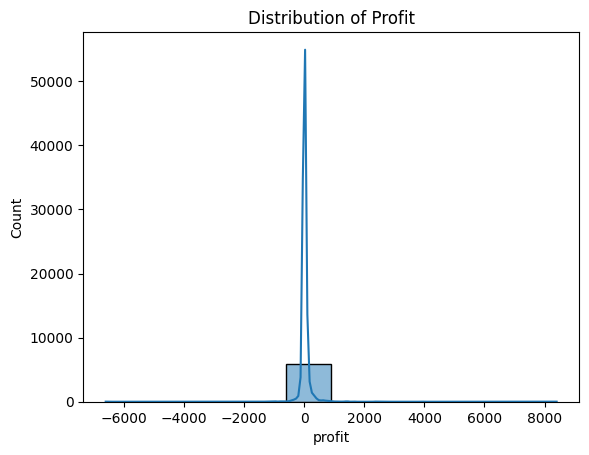

In [ ]:
sns.histplot(df['profit'], bins=10, kde=True)
plt.title("Distribution of Profit")


Text(0.5, 1.0, 'Boxplot of Profit')

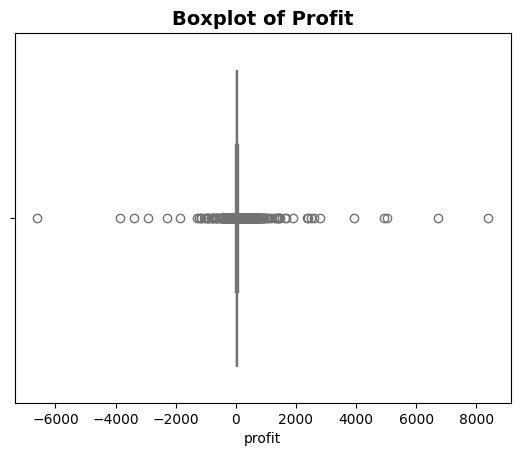

In [ ]:
sns.boxplot(x=df['profit'], color='lightgreen')
plt.title("Boxplot of Profit", fontsize=14, fontweight='bold')

Measure of central tendency  measure spread and skewness

In [ ]:
mean_profit=df['profit'].mean()
median_profit=df['profit'].median()
print(f"Mean Profit: {mean_profit}, Median Profit: {median_profit}")

std_profit=df['profit'].std()
var_profit=df['profit'].var()
print(f"Standard Deviation of Profit: {std_profit}, Variance of Profit: {var_profit}")

skew_profit=df['profit'].skew()
print(f"Skewness of Profit: {skew_profit}")



Mean Profit: 29.70040771055753, Median Profit: 8.5025
Standard Deviation of Profit: 259.58913836397994, Variance of Profit: 67386.52075655351
Skewness of Profit: 8.433694070100984


#### Profit
*   **Summary (df.describe()):**
    *   The average profit (`mean`) is 29.70, but like sales, the `median` profit is lower at 8.50, again suggesting a right-skewed distribution.
    *   Profits range widely from a substantial loss of -6599.98 to a high profit of 8399.98.
    *   The `std` of 259.59 also indicates a large spread in profit values, with many transactions resulting in small profits or losses, and some leading to very high profits or losses.
*   **Loss/Profit Count:**
    *   1098 orders resulted in a loss, while 4764 orders generated a profit. This shows that while most orders are profitable, a significant portion incurs losses.
*   **Distribution (Histogram & Boxplot):**
    *   The histogram shows that most profit values are concentrated around zero or slightly positive, with long tails extending into both significant losses and high profits. It's heavily skewed towards positive values, but with notable negative instances.
    *   The boxplot vividly displays numerous outliers on both the positive and negative sides, especially on the positive side, indicating both extremely profitable and unprofitable transactions.
*   **Measures of Central Tendency, Spread, and Skewness:**
    *   **Mean Profit:** 29.70
    *   **Median Profit:** 8.50
    *   **Standard Deviation of Profit:** 259.59
    *   **Variance of Profit:** 67386.52
    *   **Skewness of Profit:** 8.43. This very high positive skewness indicates a strong concentration of data towards lower profit values (including losses), with extreme positive profit values significantly influencing the mean.

####################### Quantity #######################################


In [ ]:
df['quantity'].describe()

count    5901.000000
mean        3.781901
std         2.212917
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: quantity, dtype: float64

Text(0.5, 1.0, 'Distribution of Quantity with 30 bins')

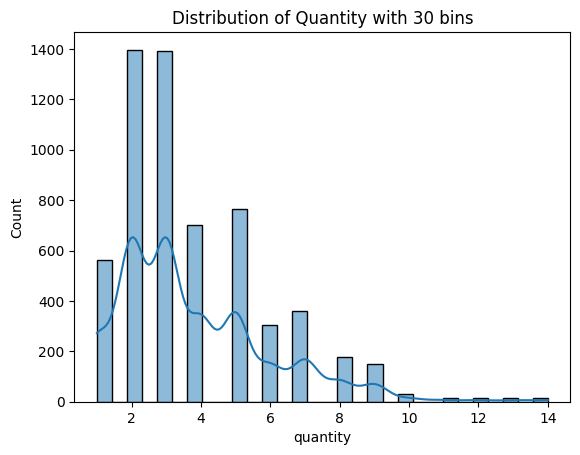

In [ ]:
sns.histplot(df['quantity'], bins=30, kde=True)
plt.title("Distribution of Quantity with 30 bins")

Text(0.5, 1.0, 'Boxplot of Quantity')

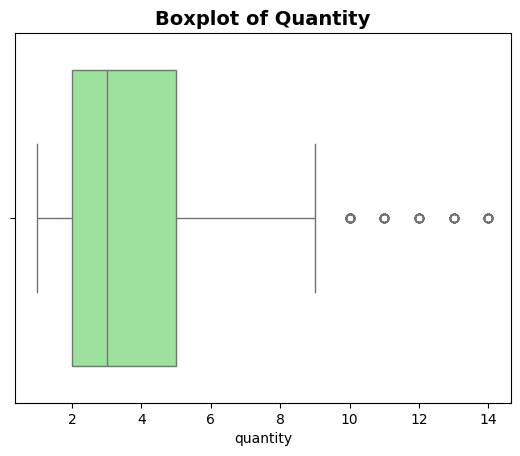

In [ ]:
sns.boxplot(x=df['quantity'], color='lightgreen')
plt.title("Boxplot of Quantity", fontsize=14, fontweight='bold')

In [ ]:
mean_quantity=df['quantity'].mean() # calcualte mean
median_quantity=df['quantity'].median()
print(f"Mean Quantity: {mean_quantity}, Median Quantity: {median_quantity}")
std_quantity=df['quantity'].std()
var_quantity=df['quantity'].var()
print(f"Standard Deviation of Quantity: {std_quantity}, Variance of Quantity: {var_quantity}")

skew_quantity=df['quantity'].skew()
print(f"Skewness of Quantity: {skew_quantity}")


Mean Quantity: 3.7819013726487034, Median Quantity: 3.0
Standard Deviation of Quantity: 2.2129168980620633, Variance of Quantity: 4.897001197728623
Skewness of Quantity: 1.21684764245536


#### Quantity
*   **Summary (df.describe()):**
    *   The average quantity (`mean`) per order is about 3.78, with a `median` of 3.0. This indicates that most orders consist of a small number of items.
    *   Quantities range from 1 to 14, which is a relatively narrow range compared to sales and profit.
    *   The `std` of 2.21 suggests that quantities are relatively clustered around the mean.
*   **Distribution (Histogram & Boxplot):**
    *   The histogram shows that most orders have quantities between 2 and 5. The distribution is also right-skewed, but less severely than sales and profit.
    *   The boxplot shows some outliers at higher quantities (e.g., 10-14 items), but the bulk of the data is within a small range.
*   **Measures of Central Tendency, Spread, and Skewness:**
    *   **Mean Quantity:** 3.78
    *   **Median Quantity:** 3.0
    *   **Standard Deviation of Quantity:** 2.21
    *   **Variance of Quantity:** 4.90
    *   **Skewness of Quantity:** 1.22. A positive skewness value around 1 indicates a moderate right-skew, meaning larger quantities, while less frequent, do occur and pull the mean slightly higher than the median.